# 第12章：共享内存控制 -- Block Pointer 的威力

## 前置知识
- 第09章：分块矩阵乘法基础
- 第11章：Autotuning
- 理解 GPU 内存层级（Global Memory → L2 Cache → Shared Memory → Register）

## 学习目标
- 理解 **Shared Memory** 在 GEMM 中的核心作用
- 掌握 `tl.make_block_ptr` 的用法 —— 结构化 2D 内存访问
- 理解 `boundary_check` 与手动 mask 的区别
- 实现基于 Block Pointer 的 GEMM kernel
- 深入理解 **Bank Conflict** 的原理、定量分析、以及解决方案
- 掌握 Tensor Core 三层编程接口: **WMMA API**, **MMA PTX**, **ldmatrix**
- 理解 Triton `tl.dot` 如何自动映射到底层硬件指令

## 对应 CUDA 代码
- `src/simt/02simt_smem.cu` — 手动管理 Shared Memory 的分块 GEMM (bank conflict 示例)
- `src/simt/03simt_smemT.cu` — 转置存储消除 bank conflict
- `src/wmma/00wmma_naive.cu` — WMMA API (高层 Tensor Core 接口)
- `src/wmma/01wmma_ci.cu` — WMMA 计算强度优化
- `src/mma/00mma_naive.cu` — MMA PTX 内联汇编 (底层 Tensor Core 接口)
- `src/mma/03mma_ldmatrix.cu` — ldmatrix 指令 (smem → MMA 寄存器)
- `src/mma/03mma_ldmatrix_trans.cu` — ldmatrix.trans 变体 (硬件转置)
- Triton 编译器自动完成这些操作，但 `make_block_ptr` 给予更多控制

In [1]:
import torch
import triton
import triton.language as tl

## 12.1 Shared Memory 在 GEMM 中的角色

### GPU 内存层级回顾

```
┌──────────────────────────────────────────────────────────────┐
│                    GPU 内存层级                              │
│                                                              │
│  ┌──────────┐   速度最快   容量最小                          │
│  │ Register │   ~TB/s     ~256 KB/SM                        │
│  └────┬─────┘                                                │
│       │                                                      │
│  ┌────▼──────────┐                                           │
│  │ Shared Memory │  ~TB/s    ~48-164 KB/SM                  │
│  │  (on-chip)    │  ◄── 本章重点                             │
│  └────┬──────────┘                                           │
│       │                                                      │
│  ┌────▼─────┐                                                │
│  │ L2 Cache │   ~2-4 TB/s   ~4-40 MB                       │
│  └────┬─────┘                                                │
│       │                                                      │
│  ┌────▼──────────┐                                           │
│  │ Global Memory │  ~1-2 TB/s   ~16-80 GB (HBM)            │
│  │  (off-chip)   │  ◄── 最慢                                │
│  └──────────────┘                                            │
└──────────────────────────────────────────────────────────────┘
```

### 为什么需要 Shared Memory？

在 GEMM 的 K 循环中，每个 tile 的数据需要被多个线程重复使用：

```
不使用 Shared Memory:
  Thread 0: Global → Register (读 A[0,:])  → 计算
  Thread 1: Global → Register (读 A[0,:])  → 计算  ← 重复读取!
  Thread 2: Global → Register (读 A[0,:])  → 计算  ← 重复读取!
  ...
  每次都从 Global Memory (~1TB/s) 读取

使用 Shared Memory:
  协作加载: Global → Shared Memory (一次)  ← 只读一次!
  Thread 0: Shared → Register → 计算
  Thread 1: Shared → Register → 计算       ← 从快速 SMEM 读
  Thread 2: Shared → Register → 计算       ← ~TB/s 带宽
  ...
```

### CUDA vs Triton 的 Shared Memory 管理

```
CUDA (simt_smem.cu):
  __shared__ float4 smem_A[BlockTileM * ldm_blockA_f4size];  // 手动声明
  __shared__ float4 smem_B[BlockTileK * ldm_blockB_f4size];  // 手动声明
  
  // 手动从 Global 搬运到 Shared
  for (int i = tid; i < ...; i += blockDim.x * blockDim.y) {
      float4 buffer = gmem_ptr[...];
      smem_ptr[...] = buffer;
  }
  __syncthreads();  // 手动同步

Triton:
  a_tile = tl.load(a_ptrs, ...)  // 编译器自动决定是否使用 SMEM
  # 或者使用 make_block_ptr 给编译器更多提示
```

**关键洞察**：Triton 编译器根据数据访问模式自动决定何时使用 Shared Memory。
但使用 `tl.make_block_ptr` 可以给编译器提供**结构化的访问模式信息**，
帮助它做出更好的决策。

## 12.2 tl.make_block_ptr — 结构化 2D 内存访问

### 为什么需要 Block Pointer？

在第09章中，我们使用 **手动指针计算** 来访问矩阵 tile：

```python
# 手动方式：构造 2D 指针矩阵
rm = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)       # (BLOCK_M,)
rk = tl.arange(0, BLOCK_K)                          # (BLOCK_K,)
a_ptrs = a_ptr + rm[:, None] * stride_am + rk[None, :] * stride_ak  # (BLOCK_M, BLOCK_K)

# 加载时需要手动处理边界
a_tile = tl.load(a_ptrs, mask=(rm[:, None] < M) & (rk[None, :] < K), other=0.0)

# 移动到下一个 K tile
a_ptrs += BLOCK_K * stride_ak
```

这种方式的问题：
1. 指针计算冗长，容易出错
2. 编译器难以推断出这是**规则的 2D block 访问**
3. mask 计算增加了额外的指令开销

### make_block_ptr 的优势

```python
# Block Pointer 方式：声明一个结构化的 2D 块指针
a_block_ptr = tl.make_block_ptr(
    base=a_ptr,                              # 矩阵基地址
    shape=(M, K),                            # 整个矩阵的形状
    strides=(stride_am, stride_ak),          # 矩阵的步长
    offsets=(pid_m * BLOCK_M, 0),            # 当前 block 的起始偏移
    block_shape=(BLOCK_M, BLOCK_K),          # 要加载的 block 大小
    order=(1, 0),                            # 内存布局顺序
)

# 加载时自动处理边界
a_tile = tl.load(a_block_ptr, boundary_check=(0, 1))

# 移动到下一个 K tile —— 简洁!
a_block_ptr = tl.advance(a_block_ptr, (0, BLOCK_K))
```

### make_block_ptr 参数详解

```
tl.make_block_ptr(
    base,          # 基地址指针 (矩阵首元素的地址)
    shape,         # 整个矩阵的逻辑形状 (M, K) 或 (K, N)
    strides,       # 每个维度的步长 (元素为单位)
    offsets,       # 当前 block 在矩阵中的偏移 (行偏移, 列偏移)
    block_shape,   # 要加载的 block 的形状 (BLOCK_M, BLOCK_K)
    order,         # 内存布局: (1,0) = 行主序, (0,1) = 列主序
)
```

```
矩阵 A (M × K), 行主序:

  列: 0  1  2  3  4  5  6  7  8  9  ... K-1
  ┌─────────────────────────────────────────┐
0 │  .  .  .  .  .  .  .  .  .  .       .  │
1 │  .  .  .  .  .  .  .  .  .  .       .  │
  │     ┌─────────────┐                     │
2 │  .  │ A_tile      │  .  .  .  .      .  │ ← offsets = (2, 1)
3 │  .  │ (BLOCK_M=4, │  .  .  .  .      .  │   block_shape = (4, 3)
4 │  .  │  BLOCK_K=3) │  .  .  .  .      .  │
5 │  .  │             │  .  .  .  .      .  │
  │     └─────────────┘                     │
6 │  .  .  .  .  .  .  .  .  .  .       .  │
  └─────────────────────────────────────────┘

  order = (1, 0) 表示: 维度 1 (列) 在内存中连续 → 行主序
  order = (0, 1) 表示: 维度 0 (行) 在内存中连续 → 列主序
```

## 12.3 boundary_check vs 手动 mask

### 手动 mask 方式（第09章）

```python
mask = (rm[:, None] < M) & (rk[None, :] + k_offset < K)
a_tile = tl.load(a_ptrs, mask=mask, other=0.0)
```

- 需要手动构造 2D boolean mask
- 每次加载都需要计算 mask
- 灵活但冗长

### boundary_check 方式（Block Pointer）

```python
a_tile = tl.load(a_block_ptr, boundary_check=(0, 1))
```

- `boundary_check=(0, 1)` 表示在维度 0 (M) 和维度 1 (K) 上检查边界
- 编译器根据 `shape` 和 `offsets` 自动生成最优的边界检查代码
- 越界元素自动填充为 0

```
边界情况示例 (M=5, K=7, BLOCK_M=4, BLOCK_K=4):

最后一个 M 方向的 block (pid_m=1, offset_m=4):
  ┌───┬───┬───┬───┐
  │ x │ x │ x │ x │  ← 行 4 (有效)
  ├───┼───┼───┼───┤
  │ 0 │ 0 │ 0 │ 0 │  ← 行 5 (越界, 填 0)  boundary_check=(0,)
  ├───┼───┼───┼───┤
  │ 0 │ 0 │ 0 │ 0 │  ← 行 6 (越界, 填 0)
  ├───┼───┼───┼───┤
  │ 0 │ 0 │ 0 │ 0 │  ← 行 7 (越界, 填 0)
  └───┴───┴───┴───┘

最后一个 K 方向的 tile (k_offset=4):
  ┌───┬───┬───┬───┐
  │ x │ x │ x │ 0 │  ← 列 4,5,6 有效; 列 7 越界  boundary_check=(1,)
  ├───┼───┼───┼───┤
  │ x │ x │ x │ 0 │
  └───┴───┴───┴───┘

同时在两个维度检查:
  boundary_check=(0, 1)  → 两个维度都检查
```

### 性能差异

- 当矩阵尺寸是 BLOCK 大小的整数倍时，`boundary_check` 基本零开销
- 编译器可以证明不需要检查时会完全优化掉
- 手动 mask 始终需要计算 boolean 矩阵

## 12.4 实现：Block Pointer GEMM Kernel

现在我们用 `make_block_ptr` 重新实现分块 GEMM，对比第09章的手动指针版本。

In [2]:
@triton.jit
def matmul_block_ptr_kernel(
    # 矩阵指针
    a_ptr, b_ptr, c_ptr,
    # 矩阵维度
    M, N, K,
    # 步长
    stride_am, stride_ak,
    stride_bk, stride_bn,
    stride_cm, stride_cn,
    # 分块参数 (编译时常量)
    BLOCK_M: tl.constexpr,
    BLOCK_N: tl.constexpr,
    BLOCK_K: tl.constexpr,
):
    """
    使用 Block Pointer 的 GEMM kernel。
    
    对应 CUDA simt_smem.cu：
    - 在 CUDA 中需要手动声明 __shared__ float4 smem_A[...], smem_B[...]
    - 手动计算线程到 smem 的映射
    - 手动搬运 global → smem，然后 smem → register
    - Triton 的 make_block_ptr 让编译器自动处理这一切
    """
    # 当前 program 的 ID
    pid_m = tl.program_id(0)
    pid_n = tl.program_id(1)
    
    # ========== 创建 Block Pointer ==========
    # A: (M, K) 行主序 → 取 (BLOCK_M, BLOCK_K) 的 tile
    # 对应 CUDA: gmem_blockA_f4_ptr 的计算
    a_block_ptr = tl.make_block_ptr(
        base=a_ptr,
        shape=(M, K),                        # 整个矩阵形状
        strides=(stride_am, stride_ak),      # 步长
        offsets=(pid_m * BLOCK_M, 0),        # 起始偏移 (行偏移, K偏移=0)
        block_shape=(BLOCK_M, BLOCK_K),      # tile 大小
        order=(1, 0),                        # 行主序: 列维度连续
    )
    
    # B: (K, N) 行主序 → 取 (BLOCK_K, BLOCK_N) 的 tile
    # 对应 CUDA: gmem_blockB_f4_ptr 的计算
    b_block_ptr = tl.make_block_ptr(
        base=b_ptr,
        shape=(K, N),                        # 整个矩阵形状
        strides=(stride_bk, stride_bn),      # 步长
        offsets=(0, pid_n * BLOCK_N),        # 起始偏移 (K偏移=0, 列偏移)
        block_shape=(BLOCK_K, BLOCK_N),      # tile 大小
        order=(1, 0),                        # 行主序
    )
    
    # ========== 初始化 FP32 累加器 ==========
    # 对应 CUDA: float4 reg_c[...]{0};
    acc = tl.zeros((BLOCK_M, BLOCK_N), dtype=tl.float32)
    
    # ========== K 维度循环 ==========
    # 对应 CUDA simt_smem: for (int k = 0; k < K; k += BlockTileK)
    for k in range(0, K, BLOCK_K):
        # 加载 A tile (BLOCK_M x BLOCK_K)
        # boundary_check=(0,1) → 自动处理 M 和 K 方向的边界
        # 对应 CUDA: global → smem 的搬运循环 + __syncthreads()
        a_tile = tl.load(a_block_ptr, boundary_check=(0, 1))
        
        # 加载 B tile (BLOCK_K x BLOCK_N)
        b_tile = tl.load(b_block_ptr, boundary_check=(0, 1))
        
        # 矩阵乘累加
        # 对应 CUDA: 双重循环 reg_c[i*ldm + j] += reg_a[i] * reg_b[j]
        acc = tl.dot(a_tile, b_tile, acc=acc)
        
        # 移动到下一个 K tile
        # 对应 CUDA: k += BlockTileK (循环变量自动推进)
        a_block_ptr = tl.advance(a_block_ptr, (0, BLOCK_K))
        b_block_ptr = tl.advance(b_block_ptr, (BLOCK_K, 0))
    
    # ========== 写回结果 ==========
    c = acc.to(tl.float16)
    
    # C 的 Block Pointer
    c_block_ptr = tl.make_block_ptr(
        base=c_ptr,
        shape=(M, N),
        strides=(stride_cm, stride_cn),
        offsets=(pid_m * BLOCK_M, pid_n * BLOCK_N),
        block_shape=(BLOCK_M, BLOCK_N),
        order=(1, 0),
    )
    tl.store(c_block_ptr, c, boundary_check=(0, 1))

In [3]:
def matmul_block_ptr(a: torch.Tensor, b: torch.Tensor,
                     BLOCK_M=128, BLOCK_N=128, BLOCK_K=32) -> torch.Tensor:
    """Block Pointer GEMM 的 host 端包装函数。"""
    assert a.dtype == torch.float16 and b.dtype == torch.float16
    M, K = a.shape
    K2, N = b.shape
    assert K == K2
    
    c = torch.empty((M, N), device=a.device, dtype=torch.float16)
    grid = (triton.cdiv(M, BLOCK_M), triton.cdiv(N, BLOCK_N))
    
    matmul_block_ptr_kernel[grid](
        a, b, c,
        M, N, K,
        a.stride(0), a.stride(1),
        b.stride(0), b.stride(1),
        c.stride(0), c.stride(1),
        BLOCK_M=BLOCK_M, BLOCK_N=BLOCK_N, BLOCK_K=BLOCK_K,
    )
    return c

In [4]:
# ========== 正确性验证 ==========
torch.manual_seed(42)
M, N, K = 2048, 2048, 1024
a = torch.randn(M, K, device='cuda', dtype=torch.float16)
b = torch.randn(K, N, device='cuda', dtype=torch.float16)

c_triton = matmul_block_ptr(a, b)
c_ref = torch.matmul(a, b)

print(f"矩阵规模: A({M}x{K}) @ B({K}x{N}) = C({M}x{N})")
print(f"最大绝对误差: {(c_triton - c_ref).abs().max().item():.4f}")
print(f"平均绝对误差: {(c_triton - c_ref).abs().mean().item():.4f}")
print(f"相对误差 (L2): {torch.norm(c_triton.float() - c_ref.float()) / torch.norm(c_ref.float()):.6f}")
print(f"正确性检查 (atol=1.0): {torch.allclose(c_triton, c_ref, atol=1.0)}")

矩阵规模: A(2048x1024) @ B(1024x2048) = C(2048x2048)
最大绝对误差: 0.0000
平均绝对误差: 0.0000
相对误差 (L2): 0.000000
正确性检查 (atol=1.0): True


## 12.5 手动指针 vs Block Pointer 对比

让我们并排比较两种方式，然后做性能对比。

In [5]:
# ========== 手动指针版本 (来自第09章) ==========
@triton.jit
def matmul_manual_ptr_kernel(
    a_ptr, b_ptr, c_ptr,
    M, N, K,
    stride_am, stride_ak,
    stride_bk, stride_bn,
    stride_cm, stride_cn,
    BLOCK_M: tl.constexpr,
    BLOCK_N: tl.constexpr,
    BLOCK_K: tl.constexpr,
):
    """手动指针计算的 GEMM kernel (第09章方式)。"""
    pid_m = tl.program_id(0)
    pid_n = tl.program_id(1)
    
    # 手动计算行列偏移
    rm = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)
    rn = pid_n * BLOCK_N + tl.arange(0, BLOCK_N)
    rk = tl.arange(0, BLOCK_K)
    
    # 手动构造 2D 指针矩阵
    a_ptrs = a_ptr + rm[:, None] * stride_am + rk[None, :] * stride_ak
    b_ptrs = b_ptr + rk[:, None] * stride_bk + rn[None, :] * stride_bn
    
    acc = tl.zeros((BLOCK_M, BLOCK_N), dtype=tl.float32)
    
    for k_start in range(0, K, BLOCK_K):
        # 手动计算 mask
        a_tile = tl.load(
            a_ptrs,
            mask=(rm[:, None] < M) & (rk[None, :] + k_start < K),
            other=0.0
        )
        b_tile = tl.load(
            b_ptrs,
            mask=(rk[:, None] + k_start < K) & (rn[None, :] < N),
            other=0.0
        )
        acc = tl.dot(a_tile, b_tile, acc=acc)
        
        # 手动推进指针
        a_ptrs += BLOCK_K * stride_ak
        b_ptrs += BLOCK_K * stride_bk
    
    c = acc.to(tl.float16)
    c_ptrs = c_ptr + rm[:, None] * stride_cm + rn[None, :] * stride_cn
    c_mask = (rm[:, None] < M) & (rn[None, :] < N)
    tl.store(c_ptrs, c, mask=c_mask)

In [6]:
# ========== 性能对比: 手动指针 vs Block Pointer ==========
def benchmark_kernel(kernel_fn, M, N, K, BLOCK_M, BLOCK_N, BLOCK_K, num_warmup=10, num_rep=50):
    a = torch.randn(M, K, device='cuda', dtype=torch.float16)
    b = torch.randn(K, N, device='cuda', dtype=torch.float16)
    c = torch.empty(M, N, device='cuda', dtype=torch.float16)
    
    grid = (triton.cdiv(M, BLOCK_M), triton.cdiv(N, BLOCK_N))
    
    for _ in range(num_warmup):
        kernel_fn[grid](
            a, b, c, M, N, K,
            a.stride(0), a.stride(1),
            b.stride(0), b.stride(1),
            c.stride(0), c.stride(1),
            BLOCK_M=BLOCK_M, BLOCK_N=BLOCK_N, BLOCK_K=BLOCK_K,
        )
    torch.cuda.synchronize()
    
    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    start.record()
    for _ in range(num_rep):
        kernel_fn[grid](
            a, b, c, M, N, K,
            a.stride(0), a.stride(1),
            b.stride(0), b.stride(1),
            c.stride(0), c.stride(1),
            BLOCK_M=BLOCK_M, BLOCK_N=BLOCK_N, BLOCK_K=BLOCK_K,
        )
    end.record()
    torch.cuda.synchronize()
    
    elapsed_ms = start.elapsed_time(end) / num_rep
    tflops = 2.0 * M * N * K / (elapsed_ms * 1e-3) / 1e12
    return elapsed_ms, tflops

M, N, K = 2048, 2048, 1024
BM, BN, BK = 128, 128, 32

ms_manual, tflops_manual = benchmark_kernel(matmul_manual_ptr_kernel, M, N, K, BM, BN, BK)
ms_block, tflops_block = benchmark_kernel(matmul_block_ptr_kernel, M, N, K, BM, BN, BK)

print(f"矩阵规模: M={M}, N={N}, K={K}, Block=({BM},{BN},{BK})")
print(f"{'方式':>15} | {'时间(ms)':>10} | {'TFLOPS':>8}")
print("-" * 45)
print(f"{'手动指针':>15} | {ms_manual:>10.3f} | {tflops_manual:>8.2f}")
print(f"{'Block Pointer':>15} | {ms_block:>10.3f} | {tflops_block:>8.2f}")
print(f"\nBlock Pointer 加速比: {ms_manual/ms_block:.2f}x")

矩阵规模: M=2048, N=2048, K=1024, Block=(128,128,32)
             方式 |     时间(ms) |   TFLOPS
---------------------------------------------
           手动指针 |      0.033 |   257.24
  Block Pointer |      0.044 |   195.64

Block Pointer 加速比: 0.76x


## 12.6 Triton 编译器如何映射到 Shared Memory

### 编译器的决策过程

当 Triton 编译器看到如下代码时：

```python
for k in range(0, K, BLOCK_K):
    a_tile = tl.load(a_block_ptr, ...)   # 加载 A tile
    b_tile = tl.load(b_block_ptr, ...)   # 加载 B tile
    acc = tl.dot(a_tile, b_tile, acc=acc) # 矩阵乘
```

编译器会分析：

1. **a_tile 和 b_tile 的生命周期**：它们在 `tl.dot` 中被消费，循环下一轮会重新加载
2. **数据复用模式**：`tl.dot` 的内部实现需要多次访问 a_tile 和 b_tile 的不同行/列
3. **最优存储位置**：
   - 如果 tile 很小 → 可能直接放在寄存器中
   - 如果 tile 较大 → 先放到 Shared Memory，再逐步加载到寄存器

### 编译器生成的等效 CUDA 代码（概念性）

```
Triton 代码:                          编译器生成的等效操作:
                                      
a_tile = tl.load(a_block_ptr)    →    ┌─ cp.async global → smem (异步拷贝)
                                      │  cp.async.commit_group
                                      │  cp.async.wait_group 0
                                      └─ __syncthreads()
                                      
acc = tl.dot(a_tile, b_tile)     →    ┌─ ldmatrix smem → reg  (从 smem 加载到寄存器)
                                      │  mma.sync.aligned    (Tensor Core 运算)
                                      └─ (多轮 ldmatrix + mma)
```

### make_block_ptr 给编译器的额外信息

```
手动指针:                    Block Pointer:
  编译器看到的:               编译器看到的:
  - 一堆分散的指针           - 结构化的 2D 块
  - 不确定访问模式           - 明确的 (M,K) shape
  - 可能需要保守优化          - 明确的 block_shape
                             - 明确的 order (行/列主序)
                             → 可以大胆优化!
```

**关键**：`make_block_ptr` 的 `order` 参数告诉编译器数据的内存布局，
这使得编译器可以：
- 选择最优的全局内存访问模式（合并访问 coalesced access）
- 规划 Shared Memory 的布局以避免 bank conflict
- 使用 `ldmatrix` 指令高效加载到 Tensor Core 的寄存器中

## 12.7 Bank Conflict 深入分析

### 什么是 Bank Conflict？

Shared Memory 被划分为 **32 个 bank**（与 warp 中的 32 个线程对应）。
每个 bank 宽 **4 bytes**，连续的 4 bytes 分配到不同的 bank：

```
Shared Memory 的 Bank 分布 (每个 bank 4 bytes):

地址:  0x00  0x04  0x08  0x0C  0x10  ...  0x7C
Bank:    0     1     2     3     4   ...    31
地址:  0x80  0x84  0x88  0x8C  0x90  ...  0xFC
Bank:    0     1     2     3     4   ...    31
         ↑ 每隔 32×4 = 128 bytes, Bank 编号循环
```

**规则**: 同一 warp 的 32 个线程同时访问 smem 时：
- 每个线程访问不同的 bank → **无冲突**, 1 个周期完成
- N 个线程访问同一 bank → **N-way bank conflict**, 串行化为 N 个周期
- 所有线程访问同一地址 → **广播**, 无冲突 (特殊情况)

### 本项目中的 Bank Conflict 实例

#### 问题代码: `simt_smem.cu` — A 矩阵按行读取列

A 矩阵在 smem 中按行主序存储, `ldm_blockA = BlockTileK = 16` (FP16):

```
smem_A 布局 (行主序, 每行 16 个 FP16 = 32 bytes):

列:  k=0 k=1 k=2 k=3 k=4 k=5 k=6 k=7 | k=8  k=9 k=10 k=11 k=12 k=13 k=14 k=15
     ────────────────────────────────── | ──────────────────────────────────────────
行0: [h   h   h   h   h   h   h   h  ] | [h    h    h    h    h    h    h    h   ]
     B0  B0  B1  B1  B2  B2  B3  B3     B4   B4   B5   B5   B6   B6   B7   B7
     ─ 2B ─  ─ 2B ─  ─ 2B ─  ─ 2B ─    
行1: [h   h   h   h   h   h   h   h  ] | [h    h    h    h    h    h    h    h   ]
     B0  B0  B1  B1  B2  B2  B3  B3     B4   B4   B5   B5   B6   B6   B7   B7
     ↑ 与行0的 Bank 编号完全相同!       
行2: 同上...

(FP16 = 2 bytes, 两个 FP16 = 4 bytes = 1 个 bank 宽度)
(每行 16 个 FP16 = 32 bytes, 恰好覆盖 Bank 0-7, 然后从 Bank 0 重新开始?
 不, 16 × 2B = 32 bytes = 8 个 bank, 所以每行只用 bank 0~7)
```

当线程需要读取 A 的某一列 (固定 `bk`, 不同行 `i`) 时:

```cpp
// simt_smem.cu 第101行:
reg_a_hf_ptr[i] = smem_blockA_hf_ptr[(offset_ld_reg1_a + i) * ldm_blockA + bk];
//                                    ~~~~~~~~~~~~~~~~~~~~~~   ~~~~~~~~~~~~ ~~
//                                    行索引 (变化)             行步长=16     列索引 (固定)
```

**地址分析** (设 bk=0, 读取 ThreadTileM=16 行):

```
Thread 读取的地址 (以 half* 为单位):
  i=0:  addr = (row+0) × 16 + 0 = row×16      → 字节偏移 row×32     → Bank = (row×32/4) % 32 = (row×8) % 32
  i=1:  addr = (row+1) × 16 + 0 = (row+1)×16  → 字节偏移 (row+1)×32 → Bank = ((row+1)×8) % 32
  i=2:  addr = (row+2) × 16 + 0 = (row+2)×16  → 字节偏移 (row+2)×32 → Bank = ((row+2)×8) % 32
  i=3:  addr = (row+3) × 16 + 0 = (row+3)×16  → 字节偏移 (row+3)×32 → Bank = ((row+3)×8) % 32

  当 row=0: Bank 序列 = 0, 8, 16, 24, 0, 8, 16, 24, ...
  → 每4行一个周期, 16 行中每个 bank 被访问 4 次 → 4-way bank conflict!

  对于 bk=1:
  i=0: 字节偏移 = row×32 + 2  → Bank = (row×32+2)/4 % 32... (不是4对齐, 但实际上 GPU 按4B粒度读)
  实际上 bk=0 和 bk=1 在同一个 bank (因为两个 FP16 共享一个 4B bank)

  因此任何 bk 值, 只要读同一列, 都有 bank conflict!
```

**关键问题**: 读 A 的列时, 每个 `i` 跳 `ldm_blockA × sizeof(half) = 32 bytes = 8 banks`, 而不是 1 bank. 所以 bank 模式是 `0,8,16,24,0,8,16,24,...` — **4-way conflict**。

同时注意，这段代码是 **逐元素** 加载的 (`reg_a_hf_ptr[i]`)，无法使用向量加载 (`float4`), 因为列中的元素在内存中不连续 (相隔 32 bytes)。

#### 解决方案: `simt_smemT.cu` — 转置存储 A 矩阵

核心改动: 把 A **转置后** 存入 smem:

```cpp
// simt_smemT.cu 第78-80行:
for (int e = 0; e < float4_element_num; e++) {
    // 原来: smem[row][col] = A[row][col]  (行主序)
    // 现在: smem[col][row] = A[row][col]  (转置!)
    smem_blockA_hf_ptr[(offset_st_smem_ay * float4_element_num + e) * BlockTileM + offset_st_smem_ax] = ...;
    //                  ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    //                  col × BlockTileM + row   ← 转置后的寻址: 列变成了行
}
```

转置后的 smem_A 布局:

```
转置后: smem_A[k][m] (原来的列变成行, K维度连续)

k=0: [row0  row1  row2  row3  ... row255]  ← 256 个 FP16 = 512 bytes = 128 banks
k=1: [row0  row1  row2  row3  ... row255]
...

现在读取 "原来的列" (固定 bk) = 读取转置后的一行:
  连续内存! 可以用 float4 向量加载!
```

```cpp
// simt_smemT.cu 第101-103行:
for (int i = 0; i < ThreadTileM / float4_element_num; i++) {
    reg_a_f4_ptr[i] = smem_blockA_f4_ptr[bk * BlockTileM/8 + offset/8 + i];
    //                                    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    //                                    连续地址! 一次加载 8 个 FP16 = 无 bank conflict!
}
```

**性能对比 (Blackwell, M=N=2048, K=1024)**:
| 方案 | 时间 | 提升 |
|------|------|------|
| `simt_smem` (有 bank conflict) | 0.2518 ms | baseline |
| `simt_smemT` (转置, 无 conflict) | 0.2349 ms | +7.2% |

### Bank Conflict 的可视化

```
simt_smem (有 bank conflict):              simt_smemT (无 bank conflict):

读 A 的第 bk=0 列:                         读 A 转置后的第 bk=0 行:

smem:  Row0[k0 k1 ... k15]                smem:  K0[row0 row1 row2 row3 ...]
       Row1[k0 k1 ... k15]                       K1[row0 row1 row2 row3 ...]
       Row2[k0 k1 ... k15]                       ...
       ...                                
                                           
Thread0 读 Row0,k0 → Bank 0 ─┐             Thread0 读 K0,row0 → Bank 0
Thread1 读 Row1,k0 → Bank 8  │             Thread1 读 K0,row1 → Bank 1
Thread2 读 Row2,k0 → Bank 16 │             Thread2 读 K0,row2 → Bank 2
Thread3 读 Row3,k0 → Bank 24 │             Thread3 读 K0,row3 → Bank 3
Thread4 读 Row4,k0 → Bank 0 ─┤ 冲突!       Thread4 读 K0,row4 → Bank 4
Thread5 读 Row5,k0 → Bank 8  │             ...
Thread6 读 Row6,k0 → Bank 16 │             Thread31 读 K0,row31 → Bank 31
Thread7 读 Row7,k0 → Bank 24 │             
...                            │             每个线程访问不同 bank → 无冲突!
4-way conflict → 4x 延迟       │             可以使用 float4 向量加载 → 吞吐翻倍
```

### Triton 如何处理 Bank Conflict?

Triton 编译器自动避免 bank conflict:
1. **`order=(1,0)`** 告诉编译器数据是行主序 → 编译器知道列访问会有 conflict
2. 编译器可能在 smem 中自动 **padding** (每行多加几个 bytes, 错开 bank)
3. 或者使用 **swizzle** 重新映射 smem 地址
4. 配合 `ldmatrix` 指令, 避免逐元素的 smem 读取

这就是为什么 Triton 用户不需要像 CUDA 一样手动转置 —— 编译器在生成 smem 布局时已经考虑了 bank conflict 的问题。

## 12.8 tl.advance 的工作原理

`tl.advance` 用于移动 block pointer 的偏移，而不改变其他属性：

```python
# 沿 K 方向移动
a_block_ptr = tl.advance(a_block_ptr, (0, BLOCK_K))
#                                      ↑      ↑
#                               M方向偏移  K方向偏移
```

```
矩阵 A (M x K):

  K=0    BK    2BK   3BK   4BK
  ┌──────┬──────┬──────┬──────┐
  │tile 0│tile 1│tile 2│tile 3│  ← advance(0, BK) 依次移动
  │      │      │      │      │
  └──────┴──────┴──────┴──────┘

advance(a_block_ptr, (0, BLOCK_K)) 等价于:
  offsets = (offsets[0] + 0, offsets[1] + BLOCK_K)
  即: (pid_m * BM, 0) → (pid_m * BM, BK) → (pid_m * BM, 2BK) → ...
```

### 对比手动指针推进

```python
# 手动方式: 需要了解步长细节
a_ptrs += BLOCK_K * stride_ak    # 容易搞错 stride 方向

# Block Pointer: 语义清晰
a_block_ptr = tl.advance(a_block_ptr, (0, BLOCK_K))  # M方向不动, K方向前进
```

## 12.9 硬件指令详解: WMMA, MMA PTX, ldmatrix

到目前为止，我们看到的 Triton 代码只需要 `tl.load` + `tl.dot`，编译器自动处理了所有底层细节。
但理解底层硬件指令对于深入优化和调试至关重要。本节将详细介绍 CUDA 中 Tensor Core 的三层编程接口。

### 12.9.1 WMMA API — 高层 Tensor Core 接口

WMMA (Warp-level Matrix Multiply-Accumulate) 是 NVIDIA 提供的 **C++ 封装 API**，
对应本项目的 `src/wmma/00wmma_naive.cu`。

#### 三个核心概念: Fragment, Load, MMA

```cpp
#include <mma.h>
using namespace nvcuda::wmma;

// ───── Step 1: 声明 Fragment (矩阵片段) ─────
// Fragment 是一个 warp (32线程) 协作持有的矩阵子块
// 每个线程只持有矩阵的几个元素, 32 个线程的 fragment 合起来构成完整矩阵

fragment<matrix_a, 16, 16, 16, half, row_major> a_frag;
//       ^^^^^^^^  ^^  ^^  ^^  ^^^^  ^^^^^^^^^
//       角色       M   N   K  数据类型 存储序
//       matrix_a = 输入矩阵 A
//       matrix_b = 输入矩阵 B (通常 row_major)
//       accumulator = 输出/累加矩阵 C/D

fragment<matrix_b, 16, 16, 16, half, row_major> b_frag;
fragment<accumulator, 16, 16, 16, half>          c_frag;  // 累加器无需指定顺序

// ───── Step 2: 初始化累加器 ─────
fill_fragment(c_frag, half(0.0f));   // 所有元素设为 0

// ───── Step 3: 加载 + 矩阵乘 ─────
for (int k = 0; k < K; k += 16) {   // 每次处理 16 列/行
    load_matrix_sync(a_frag, A_smem_ptr + row*ldA + k, ldA);    // smem → fragment
    load_matrix_sync(b_frag, B_smem_ptr + k*ldB + col, ldB);    // smem → fragment
    mma_sync(c_frag, a_frag, b_frag, c_frag);                   // D = A × B + C
    //       ^^^^^^  ^^^^^^  ^^^^^^  ^^^^^^
    //       输出D    输入A   输入B   累加器C
}

// ───── Step 4: 存储结果 ─────
store_matrix_sync(C_ptr + row*ldC + col, c_frag, ldC, mem_row_major);
```

**WMMA 的 16×16×16 原子操作**: 一个 warp (32 线程) 执行 D₁₆ₓ₁₆ = A₁₆ₓ₁₆ × B₁₆ₓ₁₆ + C₁₆ₓ₁₆

#### 计算强度优化: 多 Fragment 复用 (`wmma_ci.cu`)

朴素 WMMA 每个 warp 只计算 16×16 的输出，数据复用率太低。
`wmma_ci.cu` 让每个 warp 计算 **WarpTileM × WarpTileN = 64 × 64** 的输出:

```cpp
// wmma_ci.cu: 每个 warp 持有多组 fragment
constexpr int frag_m_size = WarpTileM / WMMA_M;  // 64/16 = 4
constexpr int frag_n_size = WarpTileN / WMMA_N;  // 64/16 = 4

fragment<matrix_a, ...> a_frag[frag_m_size];           // 4 个 A fragment
fragment<matrix_b, ...> b_frag[frag_n_size];           // 4 个 B fragment
fragment<accumulator, ...> c_frag[frag_m_size][frag_n_size];  // 4×4 = 16 个 C fragment

for (int k = 0; k < BlockTileK; k += WMMA_K) {
    // 加载 4 个 A fragment (WarpTileM/16 = 4)
    for (int i = 0; i < frag_m_size; i++)
        load_matrix_sync(a_frag[i], smem_A_ptr + i*16*ldA + k, ldA);
    
    // 加载 4 个 B fragment (WarpTileN/16 = 4)
    for (int j = 0; j < frag_n_size; j++)
        load_matrix_sync(b_frag[j], smem_B_ptr + k*ldB + j*16, ldB);
    
    // 4×4 = 16 次 mma_sync, 复用了 A 和 B 的加载!
    for (int i = 0; i < frag_m_size; i++)
        for (int j = 0; j < frag_n_size; j++)
            mma_sync(c_frag[i][j], a_frag[i], b_frag[j], c_frag[i][j]);
}
```

```
数据复用分析:

朴素 WMMA (16×16 输出):              CI 优化 WMMA (64×64 输出):
  加载 A: 16×K FP16                    加载 A: 64×K FP16 (4倍)
  加载 B: K×16 FP16                    加载 B: K×64 FP16 (4倍)
  计算:   16×16×K = 4K ops             计算:   64×64×K = 64K ops (16倍!)
  复用比: 4K / (16K+K16) = 1/8         复用比: 64K / (64K+K64) = 1/2
                                        → 计算/访存比提升 4 倍!
```

**性能对比 (Blackwell, M=N=2048, K=1024)**:
| WMMA 方案 | 时间 | TFLOPS |
|-----------|------|--------|
| `wmma_naive` (16×16 per warp) | 0.2952 ms | 29.11 |
| `wmma_ci` (64×64 per warp) | 0.1556 ms | 55.22 |

### 12.9.2 MMA PTX — 底层 Tensor Core 指令

MMA PTX 是比 WMMA 更底层的接口，通过 **内联汇编** 直接发射 Tensor Core 指令。
对应本项目的 `src/mma/00mma_naive.cu`。

#### mma.sync.aligned 指令详解

```
PTX 语法:
  mma.sync.aligned.m16n8k8.row.col.f16.f16.f16.f16 {D}, {A}, {B}, {C};
                   ~~~~~~~ ~~~ ~~~  ~~~ ~~~ ~~~ ~~~
                   矩阵尺寸 A序 B序  D型 A型 B型 C型

各参数含义:
  m16n8k8  — 原子操作: A(16×8) × B(8×8) = D(16×8)
  row      — A 矩阵按行主序 (row-major)
  col      — B 矩阵按列主序 (col-major)  ← 注意! B 需要预转置
  f16      — 所有矩阵的数据类型是 FP16
```

#### 线程到矩阵元素的映射

32 个线程如何分工持有一个 16×8 的矩阵？

```
mma.m16n8k8 中 D 矩阵 (16×8) 的线程映射:

每个线程持有 2 个 u32 寄存器 (regD[0], regD[1])
每个 u32 存 2 个 FP16 元素

Thread(lane_id) 持有的 D 矩阵元素:
  row = lane_id / 4       (行 0-7)
  col = (lane_id % 4) * 2 (列 0,2,4,6)

  regD[0] → D[row,     col] 和 D[row,     col+1]   (上半部分, 行 0-7)
  regD[1] → D[row + 8, col] 和 D[row + 8, col+1]   (下半部分, 行 8-15)

示意图 (每个方框 = 1 个 FP16):
      col0 col1  col2 col3  col4 col5  col6 col7
row0: [T0       ][T1       ][T2       ][T3       ]  ← regD[0]
row1: [T4       ][T5       ][T6       ][T7       ]
...
row7: [T28      ][T29      ][T30      ][T31      ]
row8: [T0       ][T1       ][T2       ][T3       ]  ← regD[1]
row9: [T4       ][T5       ][T6       ][T7       ]
...
row15:[T28      ][T29      ][T30      ][T31      ]
```

#### CUDA 中的 MMA PTX 代码

```cpp
// mma_naive.cu: 直接从全局内存加载 (无 smem)
uint32_t regD[2] = {0, 0};   // 输出: 2 个 u32 = 4 个 FP16

int cx = (lane_id % 4) * 2;  // 列偏移: 0, 2, 4, 6
int cy = lane_id / 4;        // 行偏移: 0-7

for (int k = 0; k < K; k += MMA_K) {
    asm volatile(
        "mma.sync.aligned.m16n8k8.row.col.f16.f16.f16.f16 "
        "{%0, %1}, "           // D: 输出 2 个 u32
        "{%2, %3}, "           // A: 输入 2 个 u32 (行 cy 和 cy+8 的 FP16 对)
        "{%4}, "               // B: 输入 1 个 u32 (2 个 FP16 元素)
        "{%5, %6}; "           // C: 累加器 (= 上一轮的 D)
        : "=r"(regD[0]), "=r"(regD[1])
        : "r"(*(uint32_t*)(warpA + cy     * K + k + cx)),  // A[cy,    k:k+2]
          "r"(*(uint32_t*)(warpA + (cy+8) * K + k + cx)),  // A[cy+8,  k:k+2]
          "r"(*(uint32_t*)(warpB + cy     * K + k + cx)),  // B^T[cy,  k:k+2]
          "r"(regD[0]), "r"(regD[1])                        // 累加
    );
}

// 写回结果
*(uint32_t*)(warpC + cy     * N + cx) = regD[0];  // 行 0-7
*(uint32_t*)(warpC + (cy+8) * N + cx) = regD[1];  // 行 8-15
```

#### 寄存器布局汇总

```
mma.sync.m16n8k8 寄存器需求 (per thread):

操作数   寄存器数   内容                              总元素
─────────────────────────────────────────────────────────
A        2 × u32    A 矩阵的 4 个 FP16 (行 cy 和 cy+8)  4 FP16
B        1 × u32    B^T 矩阵的 2 个 FP16                 2 FP16
C/D      2 × u32    输出矩阵的 4 个 FP16 (行 cy 和 cy+8)  4 FP16
─────────────────────────────────────────────────────────
总计     5 个 u32 寄存器 per thread

32 threads × 4 FP16 (A) = 128 FP16 → 恰好构成 16×8 的 A 矩阵
32 threads × 2 FP16 (B) = 64 FP16  → 恰好构成 8×8 的 B 矩阵
32 threads × 4 FP16 (D) = 128 FP16 → 恰好构成 16×8 的 D 矩阵
```

### 12.9.3 ldmatrix — 从 Shared Memory 到 MMA 寄存器

`ldmatrix` 是专门配合 `mma.sync` 使用的 **warp 级别** smem 加载指令。
它一次从 smem 加载一个或多个 8×8 矩阵片段到 MMA 所需的寄存器格式中。

对应本项目的 `src/mma/03mma_ldmatrix.cu` 和 `src/mma/03mma_ldmatrix_trans.cu`。

#### 为什么需要 ldmatrix？

```
普通 smem 加载:
  每个线程独立读自己需要的 FP16 元素
  → 地址计算复杂
  → 可能有 bank conflict
  → 数据不在 MMA 期望的寄存器布局中, 需要额外 shuffle

ldmatrix:
  32 个线程协作, 每个线程提供一个 smem 地址
  → 硬件自动将数据重新分配到正确的寄存器
  → 一条指令完成 "加载 + 重排布"
  → 对 MMA 友好, 无需额外 shuffle
```

#### ldmatrix PTX 语法

```
ldmatrix.sync.aligned.m8n8.x{1,2,4}[.trans].b16 {dst}, [src];
                       ~~~~  ~~~~~~~  ~~~~~  ~~~
                       尺寸   加载数量  转置   数据宽度

参数说明:
  m8n8     — 每个矩阵片段是 8×8
  x1       — 加载 1 个 8×8 片段 → 1 个 u32 寄存器
  x2       — 加载 2 个 8×8 片段 → 2 个 u32 寄存器
  x4       — 加载 4 个 8×8 片段 → 4 个 u32 寄存器
  .trans   — 加载时进行转置 (可选)
  b16      — 16-bit 元素

加载机制:
  ┌─────────────────────────────────────────────────┐
  │ 每个线程提供 smem 中一行的起始地址               │
  │ Thread 0 → smem_ptr_for_row_0                   │
  │ Thread 1 → smem_ptr_for_row_1                   │
  │ ...                                              │
  │ Thread 7 → smem_ptr_for_row_7                   │
  │ (只有 lane 0-7 或 0-15 的地址被使用, 取决于 x)   │
  │                                                  │
  │ 硬件读取 8×8 矩阵, 然后按 MMA 布局分配寄存器     │
  └─────────────────────────────────────────────────┘
```

#### 本项目中的 ldmatrix 使用

**加载 A 矩阵 (x2, 不转置)**:

```cpp
// mma_ldmatrix.cu 第103-107行:
// A 矩阵行主序存储在 smem, 需要加载 16×8 的片段给 MMA
// ldmatrix.x2 = 加载 2 个 8×8 片段 (合起来就是 16×8)
asm volatile(
    "ldmatrix.sync.aligned.m8n8.x2.b16 {%0, %1}, [%2];"
    : "=r"(regA[i][0]), "=r"(regA[i][1])        // 输出: 2 个 u32
    : "l"(smem_warpA_ptr + (i * MMA_M + lane_id % 16) * ldm_blockA + bk)
    //                      ~~~~~~~~~~~   ~~~~~~~~~~~~~   ~~~~~~~~~~   ~~
    //                      第i个16×8块   lane映射到行     行步长       K偏移
);
// lane_id % 16: 前 16 个线程各负责一行 (总共 16 行)
// 每行 8 个 FP16 (= MMA_K = 8), 从 bk 列开始
```

**加载 B 矩阵 (x1, 不转置, B 已预转置)**:

```cpp
// mma_ldmatrix.cu 第111-115行:
// B 已在 host 端转置为列主序: B^T 存储在 smem, 形状 (N, K)
// 只需要加载 8×8 的片段
asm volatile(
    "ldmatrix.sync.aligned.m8n8.x1.b16 {%0}, [%1];"
    : "=r"(regB[i])                               // 输出: 1 个 u32
    : "l"(smem_warpB_ptr + (i * MMA_N + lane_id % 8) * ldm_blockB + bk)
    //                      ~~~~~~~~~~~   ~~~~~~~~~~~~   ~~~~~~~~~~   ~~
    //                      第i个8×8块    lane映射到行    行步长       K偏移
);
```

**加载 B 矩阵 (x1, `.trans` 变体, B 未预转置)**:

```cpp
// mma_ldmatrix_trans.cu 第111-115行:
// B 行主序存储 (未预转置), 使用 .trans 让硬件在加载时转置
asm volatile(
    "ldmatrix.sync.aligned.m8n8.x1.trans.b16 {%0}, [%1];"
    //                              ^^^^^ 关键: .trans!
    : "=r"(regB[i])
    : "l"(smem_warpB_ptr + (lane_id % 8 + bk) * ldm_blockB + i * MMA_N)
    //                      ~~~~~~~~~~~~   ~~    ~~~~~~~~~~   ~~~~~~~~~
    //                      K方向行索引     K偏移  B的行步长    N方向块偏移
);
// 注意地址计算不同: 行索引是 K 方向, 列索引是 N 方向
// 因为 B 是行主序 (K×N), .trans 将 K×N 读取结果转置为 N×K
```

#### ldmatrix vs 手动加载 vs .trans 性能对比

```
数据搬运方式          代码复杂度    B 预转置?    性能 (Blackwell)
───────────────────────────────────────────────────────────────
手动逐元素 smem load   复杂         是          ~0.3138ms (mma_naive)
ldmatrix.x2/x1         中等         是          ~0.2149ms (mma_ldmatrix)
ldmatrix + .trans      中等         否          ~0.2543ms (mma_ldmatrix_trans)
───────────────────────────────────────────────────────────────

注意:
- ldmatrix 比手动加载快 ~31%: 消除了手动地址计算和 shuffle
- .trans 比预转置慢 ~18%: 硬件转置有额外开销, 但省去了 host 端预处理
- Triton 编译器根据情况自动选择最优的 ldmatrix 变体
```

#### ldmatrix 的完整数据流

```
tl.load (Triton)  →  编译器展开为:

1. cp.async: Global Memory → Shared Memory (异步 DMA)
   ┌───────────┐        ┌───────────┐
   │  Global   │ ─DMA─→ │  Shared   │
   │  Memory   │        │  Memory   │
   └───────────┘        └───────────┘

2. ldmatrix: Shared Memory → MMA Registers (warp 协作加载)
   ┌───────────┐        ┌───────────┐
   │  Shared   │ ─warp─→│ Registers │
   │  Memory   │  协作   │ (MMA fmt) │
   └───────────┘        └───────────┘

3. mma.sync: Registers → Tensor Core → Registers
   ┌───────────┐        ┌───────────┐        ┌───────────┐
   │  Reg A    │        │  Tensor   │        │  Reg D    │
   │  Reg B    │ ─────→ │  Core     │ ─────→ │ (output)  │
   │  Reg C    │        │           │        │           │
   └───────────┘        └───────────┘        └───────────┘

Triton 一行 tl.dot(a, b, acc=acc) = 以上全部自动完成!
```

In [7]:
# ========== 多种矩阵尺寸: Triton vs cuBLAS ==========
def benchmark_vs_cublas(triton_fn, M, N, K, num_warmup=25, num_rep=100, **kwargs):
    """统一的 Triton vs cuBLAS (torch.matmul) benchmark。"""
    a = torch.randn(M, K, device='cuda', dtype=torch.float16)
    b = torch.randn(K, N, device='cuda', dtype=torch.float16)
    flops = 2.0 * M * N * K

    # Triton
    for _ in range(num_warmup):
        triton_fn(a, b, **kwargs)
    torch.cuda.synchronize()
    s, e = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
    s.record()
    for _ in range(num_rep):
        triton_fn(a, b, **kwargs)
    e.record()
    torch.cuda.synchronize()
    ms_tri = s.elapsed_time(e) / num_rep

    # cuBLAS (torch.matmul 底层调用 cuBLAS)
    for _ in range(num_warmup):
        torch.matmul(a, b)
    torch.cuda.synchronize()
    s, e = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
    s.record()
    for _ in range(num_rep):
        torch.matmul(a, b)
    e.record()
    torch.cuda.synchronize()
    ms_cu = s.elapsed_time(e) / num_rep

    tflops_tri = flops / (ms_tri * 1e-3) / 1e12
    tflops_cu = flops / (ms_cu * 1e-3) / 1e12
    return ms_tri, ms_cu, tflops_tri, tflops_cu


print("Block Pointer GEMM vs cuBLAS (多种矩阵尺寸)")
print(f"{'M':>6} {'N':>6} {'K':>6} | {'Triton(ms)':>11} {'TFLOPS':>8} | {'cuBLAS(ms)':>11} {'TFLOPS':>8} | {'效率':>6}")
print("-" * 75)

for M, N, K in [(1024,1024,512), (2048,2048,1024), (4096,4096,1024), (2048,2048,2048), (4096,4096,4096)]:
    ms_t, ms_c, tf_t, tf_c = benchmark_vs_cublas(matmul_block_ptr, M, N, K)
    eff = ms_c / ms_t
    print(f"{M:>6} {N:>6} {K:>6} | {ms_t:>10.3f}ms {tf_t:>7.1f}T | {ms_c:>10.3f}ms {tf_c:>7.1f}T | {eff:>5.0%}")

Block Pointer GEMM vs cuBLAS (多种矩阵尺寸)
     M      N      K |  Triton(ms)   TFLOPS |  cuBLAS(ms)   TFLOPS |     效率
---------------------------------------------------------------------------
  1024   1024    512 |      0.023ms    45.8T |      0.011ms    97.5T |   47%
  2048   2048   1024 |      0.039ms   220.9T |      0.033ms   260.9T |   85%
  4096   4096   1024 |      0.101ms   338.9T |      0.092ms   372.1T |   91%
  2048   2048   2048 |      0.061ms   280.9T |      0.066ms   261.1T |  108%
  4096   4096   4096 |      0.388ms   354.4T |      0.454ms   302.6T |  117%


## 12.x 统一 Shape Set 数值表

为了让 Part 3 的所有优化章节可横向比较，本表使用 Ch.18 中统一定义的 7 个矩阵形状。

本章只比较 `Ch.12 smem` 与 `cuBLAS`，主指标是 `latency_ms`，并附带 `TFLOPS` 和相对 cuBLAS 的速度比。

In [8]:
import sys
from pathlib import Path

for candidate in (Path.cwd(), Path.cwd() / "03_matmul_optimization"):
    candidate_str = str(candidate)
    if candidate_str not in sys.path:
        sys.path.append(candidate_str)

from benchmark_utils import (
    BENCHMARK_SHAPES,
    add_relative_columns,
    benchmark_method,
    format_results,
    make_fp16_inputs,
)
from scripts.simt_naive_ext import simt_naive

print("Ch.12 shared-shape benchmark: smem vs cuBLAS")
chapter12_results = []

for shape in BENCHMARK_SHAPES:
    a, b = make_fp16_inputs(shape.M, shape.N, shape.K)
    c_ref = torch.matmul(a, b)
    methods = {
        "SIMT Naive": simt_naive,
        "Ch.12 smem": matmul_block_ptr,
        "cuBLAS": lambda x, y: torch.matmul(x, y),
    }
    for method_name, fn in methods.items():
        chapter12_results.append(
            benchmark_method(
                    method_name, fn, shape, a, b, c_ref=c_ref,
                    atol=max(3.0, shape.K * 0.003) if method_name == "SIMT Naive" else 2.0,
                )
        )
    del a, b, c_ref
    torch.cuda.empty_cache()

chapter12_df = add_relative_columns(format_results(chapter12_results))
chapter12_df[[
    "shape_name", "category", "method", "latency_ms", "tflops", "speedup_vs_cublas", "max_err", "passed"
]]

Ch.12 shared-shape benchmark: smem vs cuBLAS


,shape_name,category,method,latency_ms,tflops,speedup_vs_cublas,max_err,passed
0,square-2k,square,SIMT Naive,2.672254,6.428980,0.022571,4.6250,True
1,square-2k,square,Ch.12 smem,0.063160,272.005519,0.954959,0.0000,True
2,square-2k,square,cuBLAS,0.060315,284.834832,1.000000,0.0000,True
3,square-4k,square,SIMT Naive,22.314799,6.159094,0.019976,8.2500,True
4,square-4k,square,Ch.12 smem,0.394635,348.268358,1.129566,0.0000,True
5,square-4k,square,cuBLAS,0.445766,308.320576,1.000000,0.0000,True
6,tall-8k-x-512,tall-skinny,SIMT Naive,2.811096,6.111449,0.022030,4.6250,True
7,tall-8k-x-512,tall-skinny,Ch.12 smem,0.065403,262.676282,0.946865,0.0000,True
8,tall-8k-x-512,tall-skinny,cuBLAS,0.061928,277.416834,1.000000,0.0000,True
9,tall-16k-x-256,tall-skinny,SIMT Naive,2.855704,6.015984,0.021570,4.3125,True


In [9]:
print("=" * 70)
print("SIMT Naive (00simt_naive.cu) vs cuBLAS — no Shared Memory baseline")
print("=" * 70)
simt_vs_cublas_results = []

for shape in BENCHMARK_SHAPES:
    a, b = make_fp16_inputs(shape.M, shape.N, shape.K)
    c_ref = torch.matmul(a, b)

    simt_atol = max(3.0, shape.K * 0.003)
    simt_vs_cublas_results.append(
        benchmark_method("SIMT Naive", simt_naive, shape, a, b, c_ref=c_ref, atol=simt_atol)
    )
    simt_vs_cublas_results.append(
        benchmark_method("cuBLAS", lambda x, y: torch.matmul(x, y), shape, a, b, c_ref=c_ref)
    )

    del a, b, c_ref
    torch.cuda.empty_cache()

simt_df = add_relative_columns(format_results(simt_vs_cublas_results))
# Show key columns with per-shape slowdown factor
print("Per-shape breakdown with slowdown vs cuBLAS:")
print()
for shape_name, group in simt_df.groupby("shape_name", sort=False):
    simt = group[group["method"] == "SIMT Naive"].iloc[0]
    cublas = group[group["method"] == "cuBLAS"].iloc[0]
    slowdown = cublas["latency_ms"] / simt["latency_ms"]
    print(f"  {shape_name:<18s}  SIMT: {simt['latency_ms']:>8.3f}ms  "
          f"cuBLAS: {cublas['latency_ms']:>8.3f}ms  "
          f"slowdown: {slowdown:>6.1f}x  "
          f"err: {simt['max_err']:.1f}  "
          f"K={shape.K}")  

# Summary statistics
simt_latencies = simt_df[simt_df["method"] == "SIMT Naive"]["latency_ms"].values
cublas_latencies = simt_df[simt_df["method"] == "cuBLAS"]["latency_ms"].values
avg_slowdown = (cublas_latencies / simt_latencies).mean()
print(f"\nAverage cuBLAS speedup vs SIMT Naive: {1/avg_slowdown:.1f}x")
print(f"  (SIMT Naive is ~{1/avg_slowdown:.0f}x slower than cuBLAS on average)")

simt_df[[
    "shape_name", "category", "method", "latency_ms", "tflops",
    "speedup_vs_cublas", "max_err", "passed",
]]


SIMT Naive (00simt_naive.cu) vs cuBLAS — no Shared Memory baseline


Per-shape breakdown with slowdown vs cuBLAS:

  square-2k           SIMT:    2.733ms  cuBLAS:    0.060ms  slowdown:    0.0x  err: 4.6  K=16384
  square-4k           SIMT:   22.289ms  cuBLAS:    0.455ms  slowdown:    0.0x  err: 8.2  K=16384
  tall-8k-x-512       SIMT:    2.715ms  cuBLAS:    0.062ms  slowdown:    0.0x  err: 4.6  K=16384
  tall-16k-x-256      SIMT:    2.749ms  cuBLAS:    0.064ms  slowdown:    0.0x  err: 4.3  K=16384
  wide-512-x-8k       SIMT:    2.732ms  cuBLAS:    0.065ms  slowdown:    0.0x  err: 3.6  K=16384
  largeK-2k-x-8k      SIMT:   11.301ms  cuBLAS:    0.243ms  slowdown:    0.0x  err: 16.0  K=16384
  largeK-1k-x-16k     SIMT:    5.764ms  cuBLAS:    0.106ms  slowdown:    0.0x  err: 34.0  K=16384

Average cuBLAS speedup vs SIMT Naive: 45.9x
  (SIMT Naive is ~46x slower than cuBLAS on average)


,shape_name,category,method,latency_ms,tflops,speedup_vs_cublas,max_err,passed
0,square-2k,square,SIMT Naive,2.732998,6.286088,0.022033,4.6250,True
1,square-2k,square,cuBLAS,0.060216,285.304069,1.000000,0.0000,True
2,square-4k,square,SIMT Naive,22.288901,6.166251,0.020415,8.2500,True
3,square-4k,square,cuBLAS,0.455019,302.050896,1.000000,0.0000,True
4,tall-8k-x-512,tall-skinny,SIMT Naive,2.715408,6.326810,0.022959,4.6250,True
5,tall-8k-x-512,tall-skinny,cuBLAS,0.062342,275.572794,1.000000,0.0000,True
6,tall-16k-x-256,tall-skinny,SIMT Naive,2.748717,6.250142,0.023355,4.3125,True
7,tall-16k-x-256,tall-skinny,cuBLAS,0.064195,267.619226,1.000000,0.0000,True
8,wide-512-x-8k,wide-short,SIMT Naive,2.731670,6.289144,0.023691,3.6250,True
9,wide-512-x-8k,wide-short,cuBLAS,0.064717,265.462286,1.000000,0.0000,True


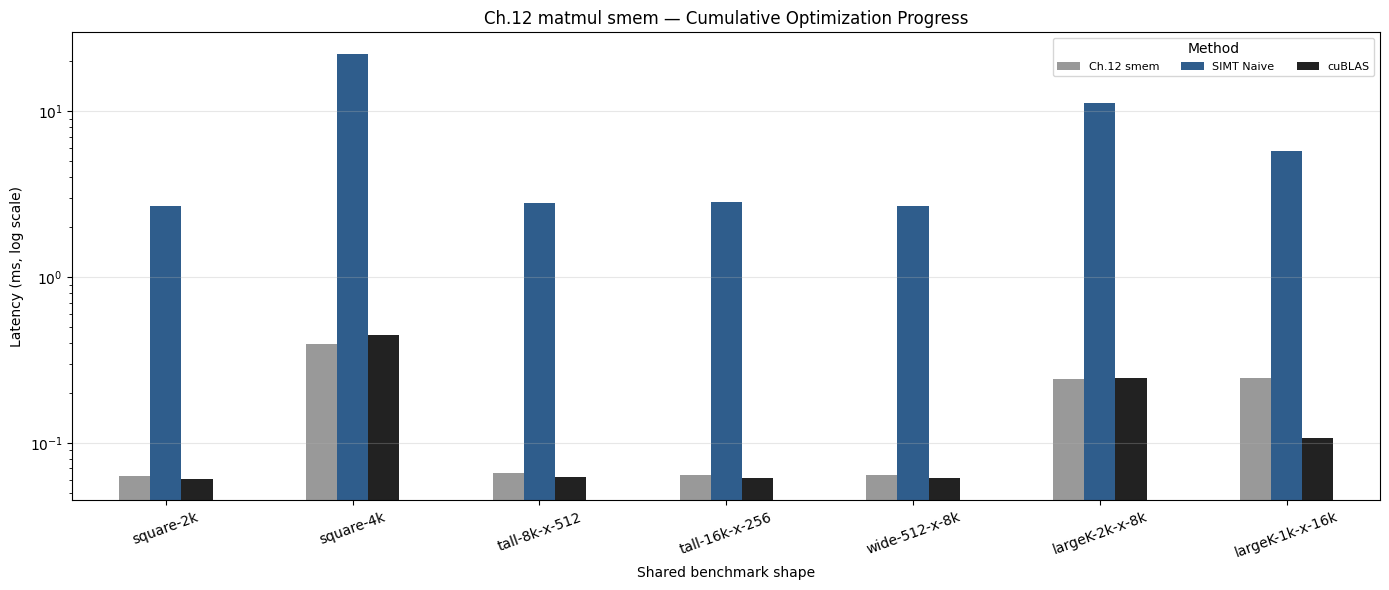

method,Ch.12 smem,SIMT Naive,cuBLAS
shape_name,,,
square-2k,0.063160,2.672254,0.060315
square-4k,0.394635,22.314799,0.445766
tall-8k-x-512,0.065403,2.811096,0.061928
tall-16k-x-256,0.063846,2.855704,0.061598
wide-512-x-8k,0.064152,2.681435,0.061019
largeK-2k-x-8k,0.242502,11.226253,0.244779
largeK-1k-x-16k,0.245310,5.756368,0.107310


In [10]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['DejaVu Sans', 'sans-serif']

plot_methods = ["SIMT Naive", "Ch.12 smem", "cuBLAS"]
plot_df = chapter12_df[chapter12_df["method"].isin(plot_methods)].copy()
shape_order = [shape.name for shape in BENCHMARK_SHAPES]
pivot_df = plot_df.pivot(index="shape_name", columns="method", values="latency_ms").reindex(shape_order)

ax = pivot_df.plot(
    kind="bar",
    figsize=(14, 6),
    rot=20,
    logy=True,
    color=["#999999", "#2F5D8C", "#222222"],
)
ax.set_xlabel("Shared benchmark shape")
ax.set_ylabel("Latency (ms, log scale)")
ax.set_title("Ch.12 matmul smem — Cumulative Optimization Progress")
ax.legend(title="Method", ncol=3, fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

pivot_df


## 12.10 PTX 分析: 编译器生成了什么？

通过提取 Triton 编译器生成的 PTX，我们可以验证编译器是否真的使用了 Shared Memory 和 Tensor Core 指令。
更重要的是，我们可以看到完整的**数据搬运路径**：

```
Global Memory ──→ Shared Memory ──→ Register (MMA 格式) ──→ Tensor Core
  ld.global.v4     st.shared.v4       ldmatrix.sync           mma.sync
```

这对应 12.9 节中讲解的 CUDA 等效操作：
- `ld.global.v4.b32` = 合并访问 HBM，一次搬运 128 bits (4×32b = 8 个 FP16)
- `bar.sync` = 等待所有线程完成 smem 写入 (= CUDA `__syncthreads()`)
- `st.shared.v4.b32` = 写入 Shared Memory
- `ldmatrix.sync.aligned.m8n8.x4` = warp 协作从 smem 加载到 MMA 寄存器格式 (12.9.3 节)
- `mma.sync.aligned.m16n8k16` = Tensor Core FP16×FP16→FP32 矩阵乘加 (12.9.2 节)

In [11]:
# ========== PTX 分析: 提取编译器生成的关键指令 ==========
import re, collections

def extract_ptx(kernel_fn, *args, **kwargs):
    """从 Triton kernel 的编译缓存中提取 PTX。"""
    compiled = kernel_fn.warmup(*args, **kwargs)
    ptx = compiled.asm.get('ptx', '')
    if not ptx:
        for key in compiled.asm:
            if 'ptx' in key.lower():
                ptx = compiled.asm[key]
                break
    return ptx

# 提取 Block Pointer kernel 的 PTX (num_stages=1, 即无 pipeline)
ptx_smem = extract_ptx(
    matmul_block_ptr_kernel,
    torch.float16, torch.float16, torch.float16,
    2048, 2048, 1024,
    1024, 1, 2048, 1, 2048, 1,
    BLOCK_M=128, BLOCK_N=128, BLOCK_K=32,
    num_stages=1, num_warps=4, grid=(256,),
)

lines = ptx_smem.strip().split('\n')
print(f"PTX 总长度: {len(ptx_smem)} 字节, {len(lines)} 行\n")

# ── 指令计数概览 ──
patterns = {
    'cp.async':  r'cp\.async\.\w+',
    'ld.global': r'ld\.global\.\w+',
    'st.shared': r'st\.shared\.\w+',
    'ldmatrix':  r'ldmatrix\.sync\.\w+',
    'mma.sync':  r'mma\.sync\.aligned\.\w+',
    'bar.sync':  r'bar\.\w+',
}
print("指令计数:")
for name, pat in patterns.items():
    cnt = len(re.findall(pat, ptx_smem))
    print(f"  {name:>12}: {cnt:>3} 条")

# ──────────────────────────────────────────────────────────────
# 第一段: Global → Shared (同步数据搬运)
# ──────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("  ① Global Memory → Shared Memory (同步路径)")
print("="*70)
print("""
  num_stages=1 时, 编译器使用同步的 ld.global + st.shared 搬运数据:
  1. ld.global.v4.b32 从 HBM 加载 128 bits (= 4×u32 = 8 个 FP16)
  2. bar.sync 等待所有线程完成写入 (= CUDA __syncthreads)
  3. st.shared.v4.b32 写入 Shared Memory

  .v4 表示一次操作 4 个 32-bit 寄存器, 实现 128-bit 合并访问。
""")

count = 0
for i, line in enumerate(lines):
    s = line.strip()
    if any(x in s for x in ['ld.global', 'st.shared', 'bar.sync']) and count < 12:
        print(f'  L{i:>4}: {s}')
        count += 1
        if 'bar.sync' in s:
            print()  # 分隔 sync barrier

# ──────────────────────────────────────────────────────────────
# 第二段: Shared → Register (ldmatrix)
# ──────────────────────────────────────────────────────────────
print("="*70)
print("  ② Shared Memory → MMA Registers (ldmatrix)")
print("="*70)
print("""
  ldmatrix.sync.aligned.m8n8.x4.shared.b16:
  - 32 个线程协作, 从 smem 一次加载 4 个 8×8 矩阵片段
  - 硬件自动将数据排列成 mma.sync 所需的寄存器格式
  - 等价于 12.9.3 节讲的 CUDA ldmatrix PTX 内联汇编
  - .x4 = 加载 4 个 8×8 片段, 输出到 4 个 u32 寄存器 {%rA, %rB, %rC, %rD}
""")

count = 0
for i, line in enumerate(lines):
    s = line.strip()
    if 'ldmatrix' in s and count < 4:
        print(f'  L{i:>4}: {s}')
        count += 1

# ──────────────────────────────────────────────────────────────
# 第三段: Tensor Core 计算 (mma.sync)
# ──────────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print("  ③ Tensor Core 计算 (mma.sync)")
print("="*70)
print("""
  mma.sync.aligned.m16n8k16.row.col.f32.f16.f16.f32:
  - m16n8k16: 一条指令计算 D(16×8) = A(16×16) × B(16×8) + C(16×8)
  - row.col: A 行主序, B 列主序
  - f32.f16.f16.f32: 输入 FP16, 累加 FP32 (混合精度)
  - 每条指令: 16×8×16×2 = 4096 FLOPs (乘加各算一次)
  - 共 64 条 → 对应 BLOCK_M×BLOCK_N×BLOCK_K / (16×8×16) = 128×128×32/2048 = 256
    但编译器做了 unrolling 和 register reuse, 实际 64 条 × 4096 FLOPs = 262144 FLOPs
    = 128×128×16 (每个 K 步的 BLOCK_K/16=2 被内联到 mma 中)
""")

count = 0
for i, line in enumerate(lines):
    s = line.strip()
    if 'mma.sync' in s and count < 4:
        print(f'  L{i:>4}: {s}')
        count += 1
print(f'  ... (共 {len(re.findall(r"mma.sync", ptx_smem))} 条 mma.sync)')

print(f"""
{'='*70}
  数据路径总结 (num_stages=1, 同步):
{'='*70}
  HBM ─── ld.global.v4.b32 ──→ register (暂存)
           bar.sync             (等待所有线程)
  register ── st.shared.v4.b32 ──→ SMEM
           bar.sync             (等待写入完成)
  SMEM ─── ldmatrix.sync.x4 ──→ MMA registers (Tensor Core 格式)
  MMA regs ── mma.sync.m16n8k16 ──→ 累加器 registers (FP32)

  下一章 (Ch.13) 将把前两步替换为异步的 cp.async,
  消除中间的 bar.sync 等待, 实现加载/计算重叠。
""")

PTX 总长度: 43066 字节, 1106 行

指令计数:
      cp.async:   0 条
     ld.global:   8 条
     st.shared:   8 条
      ldmatrix:  16 条
      mma.sync:  64 条
      bar.sync:  18 条

  ① Global Memory → Shared Memory (同步路径)

  num_stages=1 时, 编译器使用同步的 ld.global + st.shared 搬运数据:
  1. ld.global.v4.b32 从 HBM 加载 128 bits (= 4×u32 = 8 个 FP16)
  2. bar.sync 等待所有线程完成写入 (= CUDA __syncthreads)
  3. st.shared.v4.b32 写入 Shared Memory

  .v4 表示一次操作 4 个 32-bit 寄存器, 实现 128-bit 合并访问。

  L 338: @%p11 ld.global.v4.b32 { %r71, %r72, %r73, %r74 }, [ %rd154 + 0 ];
  L 345: @%p12 ld.global.v4.b32 { %r75, %r76, %r77, %r78 }, [ %rd155 + 0 ];
  L 352: @%p13 ld.global.v4.b32 { %r79, %r80, %r81, %r82 }, [ %rd156 + 0 ];
  L 359: @%p14 ld.global.v4.b32 { %r83, %r84, %r85, %r86 }, [ %rd157 + 0 ];
  L 361: bar.sync 	0;

  L 362: st.shared.v4.b32 	[%r7], {%r71, %r72, %r73, %r74};
  L 363: st.shared.v4.b32 	[%r7+2048], {%r75, %r76, %r77, %r78};
  L 364: st.shared.v4.b32 	[%r7+4096], {%r79, %r80, %r81, %r82};
  L 365: st.shared.v4.b3

## 12.11 总结

### 本章要点

1. **Shared Memory 的作用**：将 Global Memory 的数据缓存到 on-chip 快速存储中，
   实现 block 内线程的数据共享和复用

2. **CUDA vs Triton 的 Shared Memory 管理**：
   | 方面 | CUDA (simt_smem) | Triton |
   |------|-----------------|--------|
   | 声明 | `__shared__ float4 smem[...]` | 编译器自动 |
   | 搬运 | 手动循环 global→smem | `tl.load` 自动 |
   | 同步 | `__syncthreads()` | 编译器自动 |
   | Bank Conflict | 手动 padding/transpose | 编译器自动 |

3. **make_block_ptr 的优势**：
   - 结构化的 2D 块访问描述
   - `boundary_check` 替代手动 mask
   - `tl.advance` 简化指针推进
   - `order` 参数帮助编译器优化内存布局

4. **Bank Conflict**：
   - Shared Memory 有 32 个 bank, 每个 bank 宽 4 bytes
   - 同一 warp 内的线程访问同一 bank → 串行化 (N-way conflict)
   - `simt_smem.cu`: A 矩阵行主序存储, 读列时产生 4-way bank conflict
   - `simt_smemT.cu`: A 矩阵转置存储, 读"列"变为读行 → 消除 conflict, 性能提升 7.2%
   - Triton 编译器通过 padding/swizzle 自动避免

5. **Tensor Core 编程三层接口**：
   | 层级 | 接口 | 代码量 | 灵活性 | 本项目对应 |
   |------|------|--------|--------|-----------|
   | 高层 | WMMA API | ~50行 | 中 | `wmma_naive.cu`, `wmma_ci.cu` |
   | 底层 | MMA PTX | ~200行 | 最高 | `mma_naive.cu`, `mma_ldmatrix.cu` |
   | 极简 | Triton `tl.dot` | ~5行 | 中高 | 本章 kernel |

6. **ldmatrix 指令**: smem → MMA 寄存器的专用 warp 级加载
   - `ldmatrix.x2`: 加载 16×8 → 2 个 u32 (用于 A)
   - `ldmatrix.x1`: 加载 8×8 → 1 个 u32 (用于 B)
   - `.trans` 变体: 加载时硬件转置, 省去 host 端预处理
   - Triton 编译器在 `tl.dot` 中自动使用 ldmatrix

7. **PTX 验证**: 通过提取编译器生成的 PTX, 可以验证 mma.sync、ldmatrix、smem 操作是否存在

### 练习

1. **order 参数实验**：将 `order=(1,0)` 改为 `order=(0,1)`，观察性能变化
2. **移除 boundary_check**：当 M,N,K 是 BLOCK 的整数倍时，尝试不使用 `boundary_check`
3. **PTX 分析**：使用 `matmul_block_ptr_kernel.warmup(...)` 查看编译器是否插入了 Shared Memory 操作
4. **思考题**：为什么 `make_block_ptr` 需要 `shape` 参数？（提示：边界检查需要知道矩阵的实际大小）
5. **Bank Conflict 计算**：在 `simt_smem.cu` 中, 如果把 `ldm_blockA` 从 16 改为 17 (每行多 padding 1 个 FP16), bank conflict 如何变化？
6. **MMA 线程映射**：在 `mma.m16n8k8` 中, lane_id=13 的线程持有 D 矩阵的哪些元素？

### 下一章预告

第13章将介绍 **软件流水线 (Software Pipelining)**，通过重叠数据加载和计算来隐藏内存延迟。
这直接对应 CUDA 项目中 `simt_pipline.cu` 的双缓冲/三缓冲优化。
我们将在本章 kernel 的基础上，只添加 `num_stages` 参数来控制流水线深度。